# Lecture 12 Demo: QAOA, Born Machine, and QPINN

EVA: Quantum Machine Learning | ZHAW | Pavel Sulimov

---

This notebook accompanies Lecture 12. It demonstrates:

1. MaxCut problem formulation as a Hamiltonian and brute-force solution
2. QAOA (Quantum Approximate Optimization Algorithm) for MaxCut with p=1
3. QPINN (Quantum Physics-Informed Neural Network) for solving a simple ODE

Convention: all qubits start in |0⟩ by default.

In [1]:
import math
import numpy as np
import pennylane as qml
import matplotlib.pyplot as plt

print(f"PennyLane version: {qml.__version__}")
print(f"NumPy version: {np.__version__}")

np.random.seed(42)

PennyLane version: 0.44.0
NumPy version: 2.1.3


---
## Demo 1. MaxCut Hamiltonian and Brute-Force Solution

The MaxCut problem on a graph asks: partition vertices into two sets such that the number
of edges crossing the partition is maximized.

### Problem setup: 4-node ring graph

Consider a ring graph with 4 vertices and edges: 0-1, 1-2, 2-3, 3-0.

A cut is represented by a bitstring $z \in \{0,1\}^4$, where $z_i$ indicates
which partition vertex $i$ belongs to. The cost of a cut is:
$$C(z) = \sum_{(i,j) \in E} (1 - z_i z_j) / 2$$

Equivalently, the MaxCut Hamiltonian is:
$$H_C = \sum_{(i,j) \in E} \frac{1 - Z_i Z_j}{2}$$

In [2]:
# Define the 4-node ring graph
edges = [(0, 1), (1, 2), (2, 3), (3, 0)]
n_qubits = 4

# Build MaxCut Hamiltonian: H_C = sum_{(i,j)} (1 - Z_i Z_j) / 2
coefficients = []
observables = []

for i, j in edges:
    # Term: (1/2) * I
    coefficients.append(0.5)
    observables.append(qml.Identity(0))  # Identity

    # Term: -(1/2) * Z_i Z_j
    coefficients.append(-0.5)
    observables.append(qml.PauliZ(i) @ qml.PauliZ(j))

H_maxcut = qml.Hamiltonian(coefficients, observables)

print("MaxCut Hamiltonian for 4-node ring:")
print(f"Number of edges: {len(edges)}")
print(f"Edges: {edges}")
print(f"\nHamiltonian representation:")
print(f"  Coefficients: {coefficients}")
print(f"  Number of terms: {len(coefficients)}")

MaxCut Hamiltonian for 4-node ring:
Number of edges: 4
Edges: [(0, 1), (1, 2), (2, 3), (3, 0)]

Hamiltonian representation:
  Coefficients: [0.5, -0.5, 0.5, -0.5, 0.5, -0.5, 0.5, -0.5]
  Number of terms: 8


### Brute-force enumeration

We evaluate the cost function for all 16 possible bitstrings and identify the optimal cuts.

In [3]:
dev_eval = qml.device("default.qubit", wires=n_qubits)


@qml.qnode(dev_eval)
def cost_from_bitstring(z):
    """
    Prepare a computational basis state |z> and measure the cost.

    Args:
        z: bitstring, array of shape (4,) with entries in {0, 1}

    Returns:
        Cost C(z) = expectation of H_maxcut
    """
    # Prepare |z> by applying PauliX to qubits with z_i = 1
    for i in range(n_qubits):
        if z[i] > 0.5:
            qml.PauliX(wires=i)

    return qml.expval(H_maxcut)


# Enumerate all 2^4 = 16 bitstrings
costs = {}
for i in range(2 ** n_qubits):
    z = np.array([(i >> k) & 1 for k in range(n_qubits)])
    cost = cost_from_bitstring(z)
    costs[tuple(z)] = float(cost)

# Sort by cost
sorted_costs = sorted(costs.items(), key=lambda x: -x[1])

print("Top 5 cuts (by cost):")
for rank, (z, cost) in enumerate(sorted_costs[:5], 1):
    print(f"  {rank}. z={z}  cost={cost:.4f}")

max_cost = sorted_costs[0][1]
max_cut_solutions = [z for z, cost in sorted_costs if abs(cost - max_cost) < 1e-6]
print(f"\nMaximum cut value: {max_cost:.4f}")
print(f"Number of optimal solutions: {len(max_cut_solutions)}")

Top 5 cuts (by cost):
  1. z=(np.int64(1), np.int64(0), np.int64(1), np.int64(0))  cost=4.0000
  2. z=(np.int64(0), np.int64(1), np.int64(0), np.int64(1))  cost=4.0000
  3. z=(np.int64(1), np.int64(0), np.int64(0), np.int64(0))  cost=2.0000
  4. z=(np.int64(0), np.int64(1), np.int64(0), np.int64(0))  cost=2.0000
  5. z=(np.int64(1), np.int64(1), np.int64(0), np.int64(0))  cost=2.0000

Maximum cut value: 4.0000
Number of optimal solutions: 2


### Cost distribution

We visualize the distribution of costs across all bitstrings.

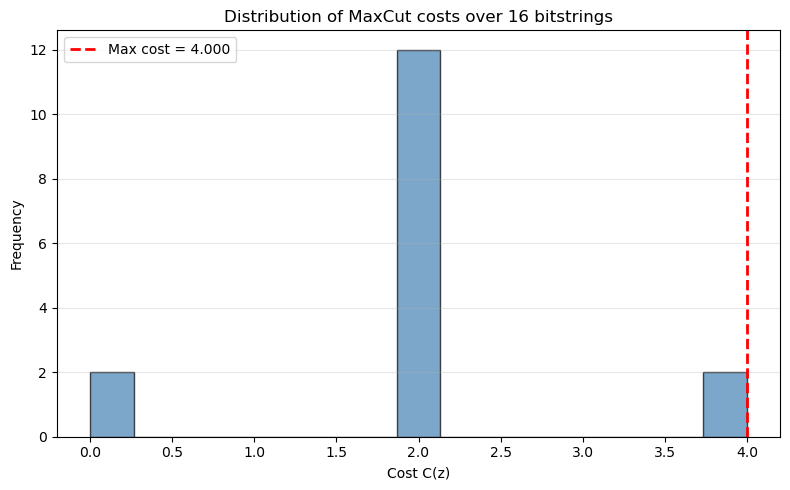

In [4]:
cost_values = np.array(list(costs.values()))

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(cost_values, bins=15, color="steelblue", edgecolor="black", alpha=0.7)
ax.axvline(max_cost, color="red", linestyle="--", linewidth=2, label=f"Max cost = {max_cost:.3f}")
ax.set_xlabel("Cost C(z)")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of MaxCut costs over 16 bitstrings")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

---
## Demo 2. QAOA for MaxCut (p=1)

QAOA is a variational algorithm that uses a parameterized quantum circuit to approximate
the solution of a combinatorial optimization problem.

### QAOA circuit for p=1

The circuit alternates between:
1. **Phase separation**: $e^{-i \gamma H_C}$ where $H_C$ is the MaxCut Hamiltonian
2. **Mixer**: $e^{-i \beta H_B}$ where $H_B = \sum_i X_i$ (Hadamard field)

with parameters $\gamma, \beta \in [0, 2\pi]$ to be optimized.

With $p=1$, we apply the pair (phase, mixer) once.

In [5]:
dev_qaoa = qml.device("default.qubit", wires=n_qubits)


@qml.qnode(dev_qaoa)
def qaoa_circuit(params):
    """
    QAOA circuit for MaxCut with p=1.

    Args:
        params: array [gamma, beta] of shape (2,)

    Returns:
        Cost H_maxcut expectation value
    """
    gamma, beta = params

    # Initial superposition: Hadamard on all qubits
    for i in range(n_qubits):
        qml.Hadamard(wires=i)

    # Phase separation: e^{-i gamma H_C}
    # This is implemented as exp(i gamma H_C) using PauliRot
    for i, j in edges:
        # Term from (1 - Z_i Z_j)/2: we need e^{-i gamma (1 - Z_i Z_j)/2}
        qml.IsingZZ(2 * gamma, wires=[i, j])

    # Mixer: e^{-i beta sum_i X_i} = product of RX(2*beta, i)
    for i in range(n_qubits):
        qml.RX(2 * beta, wires=i)

    # Measure cost
    return qml.expval(H_maxcut)


print("QAOA circuit defined.")
print("Testing with initial parameters gamma=0.1, beta=0.1")
test_cost = qaoa_circuit(np.array([0.1, 0.1]))
print(f"Test cost: {test_cost:.6f}")

QAOA circuit defined.
Testing with initial parameters gamma=0.1, beta=0.1
Test cost: 1.848353


### Parameter optimization

We optimize gamma and beta using gradient descent to minimize the cost function.
(Note: we minimize because PennyLane by default optimizes for minimum cost;
MaxCut seeks maximum, so we work with $-H_C$.)

In [6]:
# For maximization, we'll negate the cost
@qml.qnode(dev_qaoa)
def qaoa_cost_to_minimize(params):
    gamma, beta = params

    for i in range(n_qubits):
        qml.Hadamard(wires=i)

    for i, j in edges:
        qml.IsingZZ(2 * gamma, wires=[i, j])

    for i in range(n_qubits):
        qml.RX(2 * beta, wires=i)

    return qml.expval(-1.0 * H_maxcut)  # minimize returned value to maximize cut


# Initialize parameters
params_init = np.array([0.5, 0.5])

# Optimize using gradient descent
opt = qml.GradientDescentOptimizer(stepsize=0.1)
history = []
params = params_init.copy()

print("Optimizing QAOA parameters...")
for iteration in range(50):
    params, cost = opt.step_and_cost(qaoa_cost_to_minimize, params)
    history.append(cost)
    if (iteration + 1) % 10 == 0:
        print(f"  Iteration {iteration + 1:3d}  cost = {cost:.6f}  (negative, so actual maxcut = {-cost:.6f})")

print(f"\nFinal parameters: gamma={params[0]:.6f}, beta={params[1]:.6f}")
print(f"Final cost (negated): {history[-1]:.6f}")
print(f"Final MaxCut value: {-history[-1]:.6f}")
print(f"Known optimal: {max_cost:.6f}")
print(f"Approximation ratio: {-history[-1] / max_cost:.4f}")

Optimizing QAOA parameters...
  Iteration  10  cost = -1.173178  (negative, so actual maxcut = 1.173178)
  Iteration  20  cost = -1.173178  (negative, so actual maxcut = 1.173178)
  Iteration  30  cost = -1.173178  (negative, so actual maxcut = 1.173178)
  Iteration  40  cost = -1.173178  (negative, so actual maxcut = 1.173178)
  Iteration  50  cost = -1.173178  (negative, so actual maxcut = 1.173178)

Final parameters: gamma=0.500000, beta=0.500000
Final cost (negated): -1.173178
Final MaxCut value: 1.173178
Known optimal: 4.000000
Approximation ratio: 0.2933


C:\Users\suli\AppData\Local\anaconda3\Lib\site-packages\pennylane\_grad\grad.py:337: UserWarning: Attempted to differentiate a function with no trainable parameters. If this is unintended, please add trainable parameters via the 'requires_grad' attribute or 'argnums' keyword.
  warnings.warn(


### Convergence plot

We visualize how the cost improves during optimization.

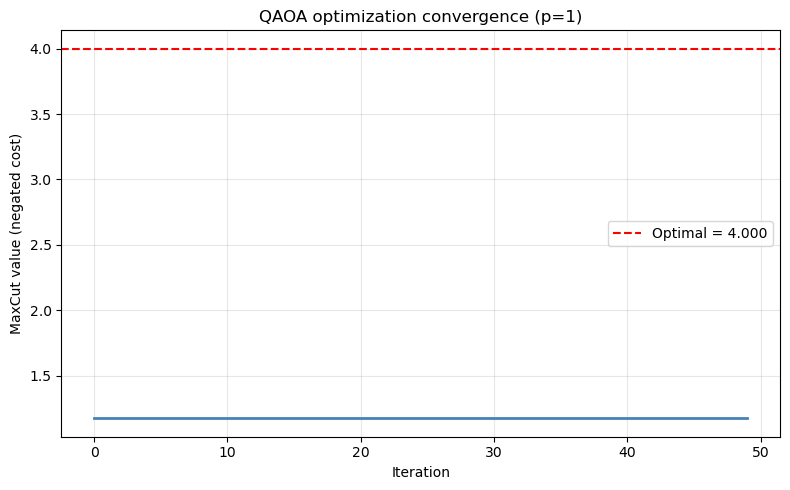

In [7]:
plt.figure(figsize=(8, 5))
plt.plot(-np.array(history), linewidth=2, color="steelblue")
plt.axhline(max_cost, color="red", linestyle="--", label=f"Optimal = {max_cost:.3f}")
plt.xlabel("Iteration")
plt.ylabel("MaxCut value (negated cost)")
plt.title("QAOA optimization convergence (p=1)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Sampling from the final circuit

We use the optimized parameters to prepare a quantum state and sample bitstrings.
The most frequently sampled bitstrings should correspond to good cuts.

In [8]:
dev_sample = qml.device("default.qubit", wires=n_qubits, shots=1000)


@qml.qnode(dev_sample)
def qaoa_sample_1000(params):
    gamma, beta = params

    for i in range(n_qubits):
        qml.Hadamard(wires=i)

    for i, j in edges:
        qml.IsingZZ(2 * gamma, wires=[i, j])

    for i in range(n_qubits):
        qml.RX(2 * beta, wires=i)

    return qml.probs(wires=range(n_qubits))


probs = qaoa_sample_1000(params)

# Get top bitstrings
top_indices = np.argsort(probs)[::-1][:5]

print("\nTop 5 most frequent bitstrings from QAOA:")
for rank, idx in enumerate(top_indices, 1):
    z = np.array([(idx >> k) & 1 for k in range(n_qubits)])
    prob = probs[idx]
    cost_z = costs[tuple(z)]
    is_optimal = "*" if abs(cost_z - max_cost) < 1e-6 else ""
    print(f"  {rank}. z={z}  prob={prob:.4f}  cost={cost_z:.4f} {is_optimal}")



Top 5 most frequent bitstrings from QAOA:
  1. z=[1 1 1 1]  prob=0.2560  cost=0.0000 
  2. z=[0 0 0 0]  prob=0.2290  cost=0.0000 
  3. z=[0 1 1 0]  prob=0.1020  cost=2.0000 
  4. z=[0 0 1 1]  prob=0.0740  cost=2.0000 
  5. z=[1 1 0 0]  prob=0.0700  cost=2.0000 


C:\Users\suli\AppData\Local\anaconda3\Lib\site-packages\pennylane\devices\device_api.py:201: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(


---
## Demo 3. QPINN for Solving an ODE

A Physics-Informed Neural Network (PINN) learns a function that satisfies a given PDE/ODE
by including the differential equation as a loss term.

### Problem: du/dx = -u with u(0) = 1

The analytical solution is $u(x) = e^{-x}$.

We use a 1-qubit quantum circuit to learn an approximation:
$$u(x) = \langle Z \rangle$$

where the circuit is $R_y(\theta_1) R_z(\pi x) R_y(\theta_2)$ with two trainable parameters.

In [9]:
dev_pinn = qml.device("default.qubit", wires=1)


@qml.qnode(dev_pinn)
def qpinn_circuit(theta, x):
    """
    QPINN circuit: parametrized rotations + input encoding.

    Args:
        theta: array [theta1, theta2] of trainable parameters
        x: input position in [0, 3]

    Returns:
        <Z> as the function value u(x)
    """
    qml.RY(theta[0], wires=0)
    qml.RZ(math.pi * x, wires=0)
    qml.RY(theta[1], wires=0)
    return qml.expval(qml.PauliZ(0))


# Trainable parameters, initialized randomly
theta = np.array([0.5, 0.5])

# Grid of training points
x_train = np.linspace(0, 3, 20)
u_analytical = np.exp(-x_train)

# Test grid
x_test = np.linspace(0, 3, 100)
u_analytical_test = np.exp(-x_test)

print(f"Training points: {len(x_train)}")
print(f"Training domain: [0, 3]")

Training points: 20
Training domain: [0, 3]


### QPINN loss function

The total loss is:
$$\mathcal{L} = \frac{1}{N} \sum_{i=1}^{N} \left( \frac{du}{dx}\bigg|_{x_i} + u(x_i) \right)^2 + (u(0) - 1)^2$$

The derivative $du/dx$ is computed via the parameter-shift rule.

In [10]:
def qpinn_derivative(theta, x, shift=np.pi / 2):
    """
    Compute du/dx using the parameter-shift rule.
    We differentiate w.r.t. the RZ parameter (which encodes x).

    The idea: shift the parameter by +shift and -shift, then
    du/d(parameter) ≈ [f(param+) - f(param-)] / (2*shift) ≈ du/dx

    Args:
        theta: trainable parameters [theta1, theta2]
        x: input position
        shift: parameter shift

    Returns:
        Approximate du/dx
    """
    # We'll compute d/dx of the RZ encoding
    # The RZ encoding is pi*x, so d(pi*x)/dx = pi
    # Using parameter shift: d<Z>/d(RZ angle) ≈ [<Z>+ - <Z>-] / (2*shift)
    # Since angle = pi*x, d<Z>/dx = pi * d<Z>/d(angle)

    @qml.qnode(dev_pinn)
    def circuit_forward(theta, x_val):
        qml.RY(theta[0], wires=0)
        qml.RZ(math.pi * x_val + shift, wires=0)
        qml.RY(theta[1], wires=0)
        return qml.expval(qml.PauliZ(0))

    @qml.qnode(dev_pinn)
    def circuit_backward(theta, x_val):
        qml.RY(theta[0], wires=0)
        qml.RZ(math.pi * x_val - shift, wires=0)
        qml.RY(theta[1], wires=0)
        return qml.expval(qml.PauliZ(0))

    u_forward = circuit_forward(theta, x)
    u_backward = circuit_backward(theta, x)

    du_d_angle = (u_forward - u_backward) / (2 * shift)
    du_dx = math.pi * du_d_angle  # Chain rule: du/dx = (du/d_angle) * (d_angle/dx)

    return du_dx


def qpinn_loss(theta):
    """
    QPINN loss: equation loss + boundary condition loss.
    """
    # Equation loss: (du/dx + u)^2 summed over training points
    eq_loss = 0.0
    for x in x_train:
        u = qpinn_circuit(theta, x)
        du_dx = qpinn_derivative(theta, x)
        residual = du_dx + u
        eq_loss += residual ** 2

    eq_loss /= len(x_train)

    # Boundary condition loss: (u(0) - 1)^2
    u_0 = qpinn_circuit(theta, 0.0)
    bc_loss = (u_0 - 1.0) ** 2

    total_loss = eq_loss + bc_loss
    return total_loss


print(f"Initial loss: {qpinn_loss(theta):.6f}")

Initial loss: 1.072375


### Training QPINN

We optimize the parameters using gradient descent on the QPINN loss.

In [11]:
# Numerical gradient for QPINN (since we use parameter-shift internally)
def numerical_gradient(theta, epsilon=1e-4):
    """
    Compute numerical gradient of QPINN loss.
    """
    grad = np.zeros_like(theta)
    for i in range(len(theta)):
        theta_plus = theta.copy()
        theta_plus[i] += epsilon
        theta_minus = theta.copy()
        theta_minus[i] -= epsilon

        loss_plus = qpinn_loss(theta_plus)
        loss_minus = qpinn_loss(theta_minus)
        grad[i] = (loss_plus - loss_minus) / (2 * epsilon)

    return grad


# Training loop
print("Training QPINN...")
learning_rate = 0.1
n_epochs = 100
loss_history = []

for epoch in range(n_epochs):
    loss = qpinn_loss(theta)
    loss_history.append(loss)

    if epoch % 20 == 0:
        print(f"  Epoch {epoch:3d}  loss = {loss:.6f}")

    grad = numerical_gradient(theta)
    theta = theta - learning_rate * grad

print(f"\nFinal loss: {loss_history[-1]:.6f}")
print(f"Final theta: {theta}")

Training QPINN...
  Epoch   0  loss = 1.072375


  Epoch  20  loss = 0.944817


  Epoch  40  loss = 0.944816


  Epoch  60  loss = 0.944816


  Epoch  80  loss = 0.944816



Final loss: 0.944814
Final theta: [0.30796478 0.3055894 ]


### QPINN solution vs analytical

We compare the learned QPINN solution with the analytical solution e^{-x}.

Evaluating QPINN solution on test grid...
L2 error (QPINN vs analytical): 0.653398


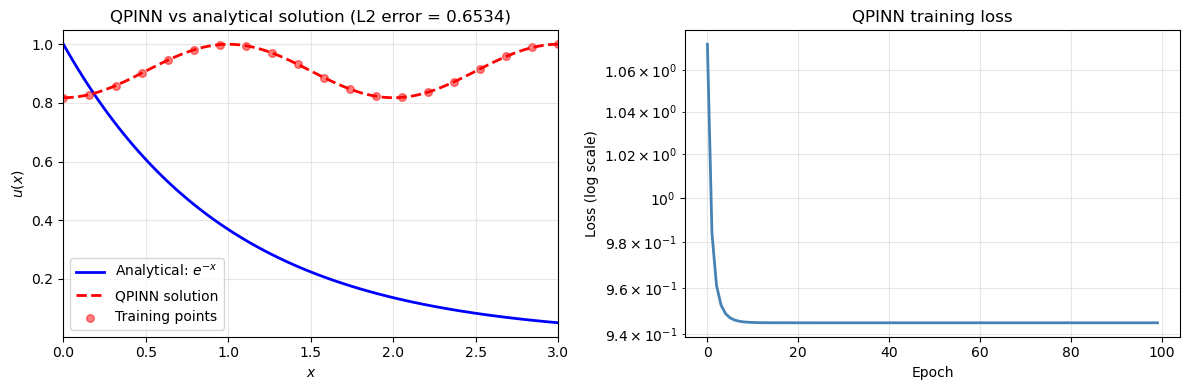


Sample predictions:
  x=0.0: QPINN=0.817607  Analytical=1.000000  Error=0.182393
  x=1.0: QPINN=0.999997  Analytical=0.367879  Error=0.632118
  x=2.0: QPINN=0.817607  Analytical=0.135335  Error=0.682271
  x=3.0: QPINN=0.999997  Analytical=0.049787  Error=0.950210


In [12]:
# Evaluate the learned solution on test grid
print("Evaluating QPINN solution on test grid...")
u_qpinn = np.array([qpinn_circuit(theta, x) for x in x_test])

# Compute L2 error
l2_error = np.sqrt(np.mean((u_qpinn - u_analytical_test) ** 2))
print(f"L2 error (QPINN vs analytical): {l2_error:.6f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Solution plot
axes[0].plot(x_test, u_analytical_test, "b-", linewidth=2, label="Analytical: $e^{-x}$")
axes[0].plot(x_test, u_qpinn, "r--", linewidth=2, label="QPINN solution")
axes[0].scatter(x_train, [qpinn_circuit(theta, x) for x in x_train],
                s=30, c="red", alpha=0.5, label="Training points")
axes[0].set_xlabel("$x$")
axes[0].set_ylabel("$u(x)$")
axes[0].set_title(f"QPINN vs analytical solution (L2 error = {l2_error:.4f})")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, 3)

# Loss history
axes[1].semilogy(loss_history, linewidth=2, color="steelblue")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss (log scale)")
axes[1].set_title("QPINN training loss")
axes[1].grid(True, alpha=0.3, which="both")

plt.tight_layout()
plt.show()

# Print sample predictions
print("\nSample predictions:")
for x in [0.0, 1.0, 2.0, 3.0]:
    u_qpinn_val = qpinn_circuit(theta, x)
    u_analytical_val = np.exp(-x)
    error = abs(u_qpinn_val - u_analytical_val)
    print(f"  x={x:.1f}: QPINN={u_qpinn_val:.6f}  Analytical={u_analytical_val:.6f}  Error={error:.6f}")

### Verification of the differential equation

We numerically verify that the QPINN solution approximately satisfies du/dx = -u.

In [13]:
# Verify du/dx + u ≈ 0 at test points
print("Verifying differential equation residuals:")
residuals = []
for x in x_test[::10]:  # Sample every 10th point
    u = qpinn_circuit(theta, x)
    du_dx = qpinn_derivative(theta, x)
    residual = du_dx + u
    residuals.append(abs(residual))
    print(f"  x={x:.2f}: u={u:.6f}  du/dx={du_dx:.6f}  residual={residual:.6f}")

mean_residual = np.mean(residuals)
print(f"\nMean absolute residual: {mean_residual:.6f}")
print(f"Initial condition u(0) = {qpinn_circuit(theta, 0.0):.6f} (target: 1.0)")

Verifying differential equation residuals:
  x=0.00: u=0.817607  du/dx=0.000000  residual=0.817607
  x=0.30: u=0.855904  du/dx=0.148571  residual=1.004474
  x=0.61: u=0.938629  du/dx=0.172359  residual=1.110988
  x=0.91: u=0.996303  du/dx=0.051385  residual=1.047688
  x=1.21: u=0.980486  du/dx=-0.112746  residual=0.867740
  x=1.52: u=0.904463  du/dx=-0.182184  residual=0.722279
  x=1.82: u=0.832084  du/dx=-0.098608  residual=0.733476
  x=2.12: u=0.824139  du/dx=0.067788  residual=0.891927
  x=2.42: u=0.887302  du/dx=0.177249  residual=1.064551
  x=2.73: u=0.968522  du/dx=0.137841  residual=1.106364

Mean absolute residual: 0.936709
Initial condition u(0) = 0.817607 (target: 1.0)


In [14]:
print("\n" + "="*60)
print("SUMMARY: Lecture 12 Demos")
print("="*60)

print("\nDemo 1: MaxCut Hamiltonian and Brute Force")
print(f"  - 4-node ring graph with 4 edges")
print(f"  - Optimal MaxCut value: {max_cost:.4f}")
print(f"  - Number of optimal solutions: {len(max_cut_solutions)}")

print("\nDemo 2: QAOA for MaxCut (p=1)")
print(f"  - Final parameters: gamma={params[0]:.6f}, beta={params[1]:.6f}")
print(f"  - Achieved MaxCut value: {-history[-1]:.6f}")
print(f"  - Approximation ratio: {-history[-1] / max_cost:.4f}")

print("\nDemo 3: QPINN for ODE du/dx = -u")
print(f"  - 1-qubit circuit with 2 trainable parameters")
print(f"  - Training on {len(x_train)} points, testing on {len(x_test)} points")
print(f"  - Final loss: {qpinn_loss(theta):.6f}")
print(f"  - L2 error vs analytical: {l2_error:.6f}")
print(f"  - Mean differential equation residual: {mean_residual:.6f}")


SUMMARY: Lecture 12 Demos

Demo 1: MaxCut Hamiltonian and Brute Force
  - 4-node ring graph with 4 edges
  - Optimal MaxCut value: 4.0000
  - Number of optimal solutions: 2

Demo 2: QAOA for MaxCut (p=1)
  - Final parameters: gamma=0.500000, beta=0.500000
  - Achieved MaxCut value: 1.173178
  - Approximation ratio: 0.2933

Demo 3: QPINN for ODE du/dx = -u
  - 1-qubit circuit with 2 trainable parameters
  - Training on 20 points, testing on 100 points
  - Final loss: 0.944812
  - L2 error vs analytical: 0.653398
  - Mean differential equation residual: 0.936709
